## 0. Imports & helper parsers

In [ ]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# Centralized plot style
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42


### Helpers to parse nested columns

In [46]:
def parse_dict_cell(x):
    """Safely turn a stringified dict/list into Python object."""
    if pd.isna(x):
        return None
    if isinstance(x, (dict, list)):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return None

def extract_is_oa(open_access_cell):
    """Return bool is_oa from open_access dict."""
    d = parse_dict_cell(open_access_cell)
    if isinstance(d, dict):
        return d.get("is_oa")
    return None

def extract_source_name(primary_location_cell):
    """Return journal/source display_name from primary_location."""
    pl = parse_dict_cell(primary_location_cell)
    if isinstance(pl, dict):
        src = pl.get("source") or {}
        return src.get("display_name")
    return None

def extract_issn_l(primary_location_cell):
    pl = parse_dict_cell(primary_location_cell)
    if isinstance(pl, dict):
        src = pl.get("source") or {}
        return src.get("issn_l")
    return None

def topics_from_cols(row):
    """
    Return list of topic / concept names.
    Priority: topics_parsed (if present & not null) 
              else concepts_parsed 
              else topics column.
    """
    # use topics_parsed if you already created that as semicolon string
    tp = row.get("topics_parsed")
    if isinstance(tp, str) and tp.strip():
        return [t.strip() for t in tp.split(";") if t.strip()]
    
    cp = row.get("concepts_parsed")
    if isinstance(cp, str) and cp.strip():
        return [t.strip() for t in cp.split(";") if t.strip()]
    
    # fall back to raw topics list of dicts
    t_raw = parse_dict_cell(row.get("topics"))
    if isinstance(t_raw, list):
        return [t.get("display_name") for t in t_raw if isinstance(t, dict)]
    
    return []

def extract_concepts_list(row):
    """
    Clean list of concept names for one work.
    Priority:
      1) concepts_parsed (semicolon string you created earlier)
      2) concepts (list of dicts from OpenAlex)
    """
    # 1) use concepts_parsed if available
    cp = row.get("concepts_parsed")
    if isinstance(cp, str) and cp.strip():
        return [c.strip() for c in cp.split(";") if c.strip()]

    # 2) fall back to raw concepts list
    c_raw = parse_dict_cell(row.get("concepts"))
    if isinstance(c_raw, list):
        return [c.get("display_name") for c in c_raw
                if isinstance(c, dict) and c.get("display_name")]

    # nothing usable
    return []


### extractor for concepts

In [47]:

def parse_dict_cell(x):
    """Convert stringified lists/dicts to Python objects."""
    if pd.isna(x):
        return None
    if isinstance(x, (list, dict)):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return None

def parse_maybe_string(x):
    """Turn a string repr of list/dict into a Python object, otherwise return x."""
    if pd.isna(x):
        return None
    if isinstance(x, (list, dict)):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return x  # leave as string if it can't be parsed
    return x

def extract_concept_names(row):
    """
    Return a flat list of concept display_names for one row.
    Priority:
      1) concepts_parsed (semicolon string) if present and non-empty
      2) concepts (in whatever ugly format) → list of dicts → display_name
    """
    # 1) use concepts_parsed if available and looks like a ;-separated string
    cp = row.get("concepts_parsed")
    if isinstance(cp, str) and ";" in cp:
        return [c.strip() for c in cp.split(";") if c.strip()]

    # 2) work from 'concepts'
    c_raw = row.get("concepts")
    c_raw = parse_maybe_string(c_raw)

    # Case A: already list of dicts
    if isinstance(c_raw, list):
        # Sometimes it's ["[{'display_name': ...}, ...]"]
        if len(c_raw) == 1 and isinstance(c_raw[0], str):
            inner = parse_maybe_string(c_raw[0])
        else:
            inner = c_raw
    else:
        inner = c_raw

    # If inner is still a string, maybe it’s a list repr
    if isinstance(inner, str):
        inner = parse_maybe_string(inner)

    # Now we expect inner to be either list-of-dicts or list-of-list-of-dicts
    names = []

    if isinstance(inner, list):
        # [dict, dict, ...]
        if inner and isinstance(inner[0], dict):
            dict_list = inner
        # [[dict, dict, ...]]
        elif inner and isinstance(inner[0], list):
            dict_list = inner[0]
        else:
            dict_list = []

        for d in dict_list:
            if isinstance(d, dict):
                name = d.get("display_name")
                if name:
                    names.append(name)

    return names


### for topics

In [50]:
def extract_topic_names(row):
    """
    Return a flat list of topic display_names for one work.

    Priority:
      1) topics_parsed (semicolon string, if present)
      2) topics (raw OpenAlex list-of-dicts, possibly stringified or nested)
    """
    # 1) topics_parsed if available
    tp = row.get("topics_parsed")
    if isinstance(tp, str) and ";" in tp:
        return [t.strip() for t in tp.split(";") if t.strip()]

    # 2) fall back to 'topics'
    t_raw = row.get("topics")
    t_raw = parse_maybe_string(t_raw)

    # handle list / nested list / string
    if isinstance(t_raw, list):
        # e.g. ["[{'display_name': ...}, ...]"]
        if len(t_raw) == 1 and isinstance(t_raw[0], str):
            inner = parse_maybe_string(t_raw[0])
        else:
            inner = t_raw
    else:
        inner = t_raw

    if isinstance(inner, str):
        inner = parse_maybe_string(inner)

    names = []
    if isinstance(inner, list):
        # [dict, dict, ...] OR [[dict, dict, ...]]
        if inner and isinstance(inner[0], dict):
            dict_list = inner
        elif inner and isinstance(inner[0], list):
            dict_list = inner[0]
        else:
            dict_list = []

        for d in dict_list:
            if isinstance(d, dict):
                name = d.get("display_name")
                if name:
                    names.append(name)

    return names




## 1. Load ALL and STRICT data

In [51]:
df_all = pd.read_csv("open_alex_raw_flagged.csv")   # or your filename
df_strict = pd.read_csv("openalex_works_strict_q1_q3.csv")

print("ALL shape:", df_all.shape)
print("STRICT shape:", df_strict.shape)


ALL shape: (9689, 29)
STRICT shape: (5064, 41)


### Add derived columns needed for both:


In [52]:
for df in [df_all, df_strict]:
    # is_oa
    df["is_oa"] = df["open_access"].apply(extract_is_oa)
    
    # source name & issn_l
    df["source_name"] = df["primary_location"].apply(extract_source_name)
    df["issn_l"] = df["primary_location"].apply(extract_issn_l)
    
    # build concepts_list for BOTH datasets
    for df in (df_all, df_strict):
        df["concepts_list"] = df.apply(extract_concept_names, axis=1)
    # (Re)create topics_list on both dataframes
    for df in (df_all, df_strict):
        df["topics_list"] = df.apply(extract_topic_names, axis=1)

#### quick sanity check

In [53]:
print("ALL – sample concepts_list:")
print(df_all["concepts_list"].head().tolist())

print("\nSTRICT – sample concepts_list:")
print(df_strict["concepts_list"].head().tolist())

print("ALL – sample topics_list:")
print(df_all["topics_list"].head().tolist())

print("\nSTRICT – sample topics_list:")
print(df_strict["topics_list"].head().tolist())



ALL – sample concepts_list:
[['Curriculum', 'Computer science', 'Field (mathematics)', 'Engineering ethics', 'Knowledge management', 'Management science', 'Psychology', 'Pedagogy', 'Engineering', 'Pure mathematics', 'Mathematics'], ['Data science', 'Learning analytics', 'Computer science', 'Analytics', 'Big data', 'Educational data mining', 'Data analysis', 'Software analytics', 'Cultural analytics', 'Educational research', 'World Wide Web', 'Semantic analytics', 'Data mining', 'Software', 'Sociology', 'Social science', 'Data Web', 'Software system', 'Software construction', 'Web service', 'Programming language'], ['Autonomy', 'Engineering ethics', 'Underpinning', 'Trustworthiness', 'Set (abstract data type)', 'Thematic analysis', 'Psychology', 'Knowledge management', 'Public relations', 'Political science', 'Sociology', 'Computer science', 'Qualitative research', 'Engineering', 'Social psychology', 'Social science', 'Law', 'Civil engineering', 'Programming language'], ['Metacognition'

## 2. Step 1 – Descriptives for ALL layer

### 2.1 Publications per year (ALL)

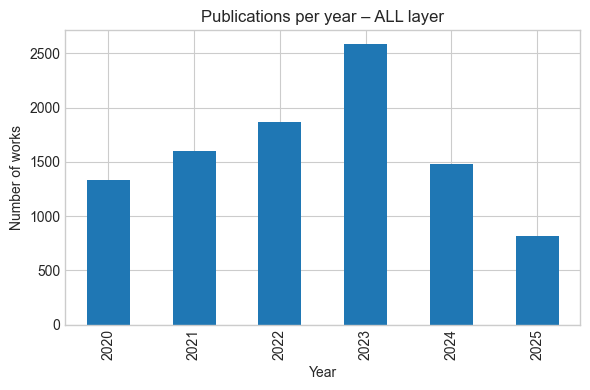

In [54]:
pubs_year_all = df_all.groupby("publication_year")["id"].count()

plt.figure(figsize=(6,4))
pubs_year_all.plot(kind="bar")
plt.title("Publications per year – ALL layer")
plt.xlabel("Year")
plt.ylabel("Number of works")
plt.tight_layout()
plt.show()


### 2.2 OA share (ALL)

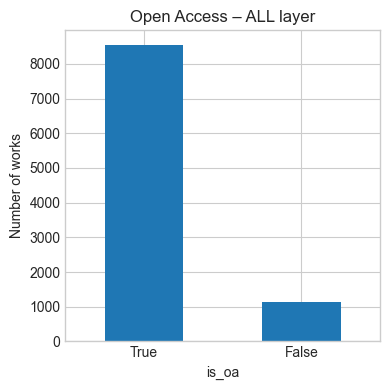

OA share (ALL): 0.8815151202394468


In [55]:
oa_counts_all = df_all["is_oa"].value_counts(dropna=False)

plt.figure(figsize=(4,4))
oa_counts_all.plot(kind="bar")
plt.xticks(rotation=0)
plt.title("Open Access – ALL layer")
plt.xlabel("is_oa")
plt.ylabel("Number of works")
plt.tight_layout()
plt.show()

print("OA share (ALL):", oa_counts_all.get(True,0) / oa_counts_all.sum())


### 2.3 Top 10 venues (ALL)

In [56]:
top_sources_all = (
    df_all["source_name"]
    .value_counts()
    .head(10)
    .rename("works_count")
    .reset_index()
    .rename(columns={"index": "source_name"})
)

display(top_sources_all)


,source_name,works_count
0,IEEE Access,186
1,Education Sciences,178
2,Lecture notes in computer science,154
3,Applied Sciences,135
4,Sustainability,127
5,Zenodo (CERN European Organization for Nuclear...,126
6,Frontiers in Education,113
7,Education and Information Technologies,95
8,Frontiers in Psychology,94
9,Electronics,82


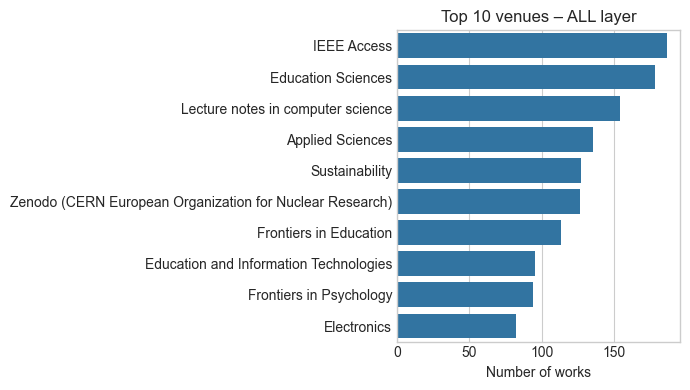

In [57]:
plt.figure(figsize=(7,4))
sns.barplot(data=top_sources_all, x="works_count", y="source_name")
plt.title("Top 10 venues – ALL layer")
plt.xlabel("Number of works")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 2.4 Top EU institutions (ALL) – simple version

In [58]:
def extract_institutions(authorships_cell):
    auths = parse_dict_cell(authorships_cell)
    insts = []
    if isinstance(auths, list):
        for a in auths:
            for inst in a.get("institutions", []):
                name = inst.get("display_name")
                ccode = inst.get("country_code")
                if name:
                    insts.append((name, ccode))
    return insts

# build a long dataframe: each row = one (work, institution)
rows = []
for _, row in df_all[["id", "authorships"]].iterrows():
    insts = extract_institutions(row["authorships"])
    for name, ccode in insts:
        rows.append({"work_id": row["id"], "institution_name": name, "country_code": ccode})

inst_all = pd.DataFrame(rows)
print("Institution rows (ALL):", inst_all.shape)

top_institutions_all = (
    inst_all.groupby(["institution_name", "country_code"])["work_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .rename("works_count")
    .reset_index()
)

display(top_institutions_all)


Institution rows (ALL): (49822, 3)


,institution_name,country_code,works_count
0,Utrecht University,NL,147
1,University of Eastern Finland,FI,118
2,Delft University of Technology,NL,101
3,Universidad de Salamanca,ES,100
4,KTH Royal Institute of Technology,SE,100
5,Centre National de la Recherche Scientifique,FR,99
6,Technical University of Munich,DE,98
7,University of Oulu,FI,98
8,KU Leuven,BE,96
9,Universidad de Granada,ES,92


### 2.5 Top 10 concepts (ALL)

,concept,count
0,Computer science,7794
1,Psychology,4805
2,Artificial intelligence,3856
3,Mathematics education,2783
4,Political science,2281
5,Philosophy,2107
6,Engineering,2091
7,Data science,2014
8,Mathematics,1905
9,Law,1769


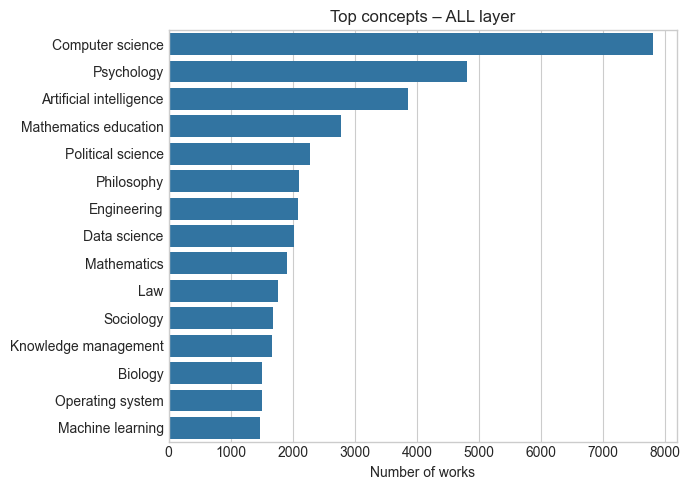

In [59]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# flatten and drop empties
all_concepts_flat = [
    c
    for lst in df_all["concepts_list"]
    if lst
    for c in lst
]

concept_counts_all = Counter(all_concepts_flat)

top_concepts_all = (
    pd.Series(concept_counts_all)
    .sort_values(ascending=False)
    .head(15)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "concept"})
)

display(top_concepts_all)

plt.figure(figsize=(7,5))
sns.barplot(data=top_concepts_all, x="count", y="concept")
plt.title("Top concepts – ALL layer")
plt.xlabel("Number of works")
plt.ylabel("")
plt.tight_layout()
plt.show()


### 2.6 Top 10 topics (ALL)

,topic,count
0,Online Learning and Analytics,2677
1,E-Learning and Knowledge Management,941
2,Innovative Teaching and Learning Methods,885
3,Intelligent Tutoring Systems and Adaptive Lear...,711
4,Online and Blended Learning,625
5,Educational Games and Gamification,567
6,Artificial Intelligence in Healthcare and Educ...,520
7,Topic Modeling,468
8,Educational Innovations and Technology,417
9,Teaching and Learning Programming,354


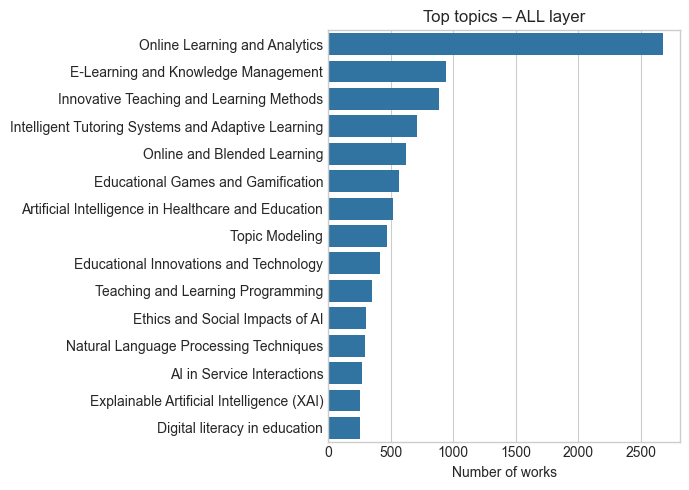

In [60]:

# flatten, drop empties
all_topics_flat = [
    t
    for lst in df_all["topics_list"]
    if lst
    for t in lst
]

topic_counts_all = Counter(all_topics_flat)

top_topics_all = (
    pd.Series(topic_counts_all)
    .sort_values(ascending=False)
    .head(15)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "topic"})
)

display(top_topics_all)

plt.figure(figsize=(7,5))
sns.barplot(data=top_topics_all, x="count", y="topic")
plt.title("Top topics – ALL layer")
plt.xlabel("Number of works")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 3. Step 2 – Descriptives for STRICT layer

### 3.1 Publications per year (STRICT)

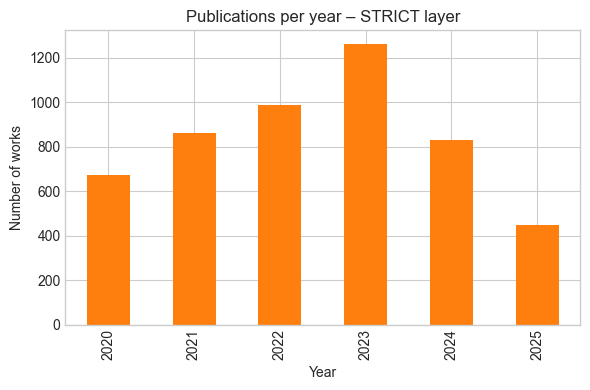

In [61]:
pubs_year_strict = df_strict.groupby("publication_year")["id"].count()

plt.figure(figsize=(6,4))
pubs_year_strict.plot(kind="bar", color="tab:orange")
plt.title("Publications per year – STRICT layer")
plt.xlabel("Year")
plt.ylabel("Number of works")
plt.tight_layout()
plt.show()


### 3.2 OA share (STRICT)

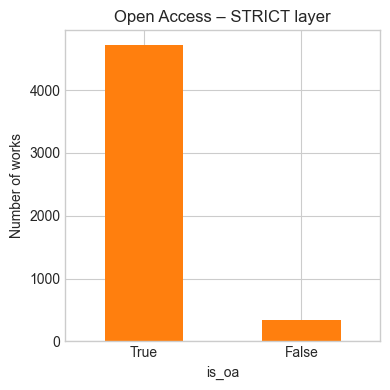

OA share (STRICT): 0.9310821484992101


In [62]:
oa_counts_strict = df_strict["is_oa"].value_counts(dropna=False)

plt.figure(figsize=(4,4))
oa_counts_strict.plot(kind="bar", color="tab:orange")
plt.xticks(rotation=0)
plt.title("Open Access – STRICT layer")
plt.xlabel("is_oa")
plt.ylabel("Number of works")
plt.tight_layout()
plt.show()

print("OA share (STRICT):", oa_counts_strict.get(True,0) / oa_counts_strict.sum())


### 3.3 Top sources (STRICT) with SJR quartile

In [63]:
top_sources_strict = (
    df_strict.groupby(["source_name", "sjr_quartile"])["id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .rename("works_count")
    .reset_index()
)

display(top_sources_strict)


,source_name,sjr_quartile,works_count
0,IEEE Access,Q1,186
1,Education Sciences,Q1,178
2,Lecture notes in computer science,Q2,154
3,Applied Sciences,Q2,135
4,Sustainability,Q1,127
5,Frontiers in Education,Q2,113
6,Education and Information Technologies,Q1,95
7,Frontiers in Psychology,Q2,94
8,Electronics,Q2,82
9,Sensors,Q1,79


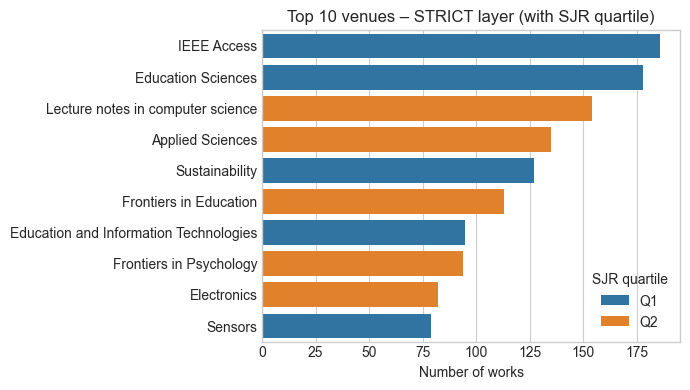

In [64]:
plt.figure(figsize=(7,4))
sns.barplot(data=top_sources_strict, x="works_count", y="source_name", hue="sjr_quartile")
plt.title("Top 10 venues – STRICT layer (with SJR quartile)")
plt.xlabel("Number of works")
plt.ylabel("")
plt.legend(title="SJR quartile")
plt.tight_layout()
plt.show()

### 3.4 Top concepts (STRICT)

,concept,count
0,Computer science,4168
1,Psychology,2769
2,Artificial intelligence,2092
3,Mathematics education,1629
4,Political science,1204
5,Philosophy,1080
6,Engineering,1066
7,Mathematics,1062
8,Law,1043
9,Data science,1038


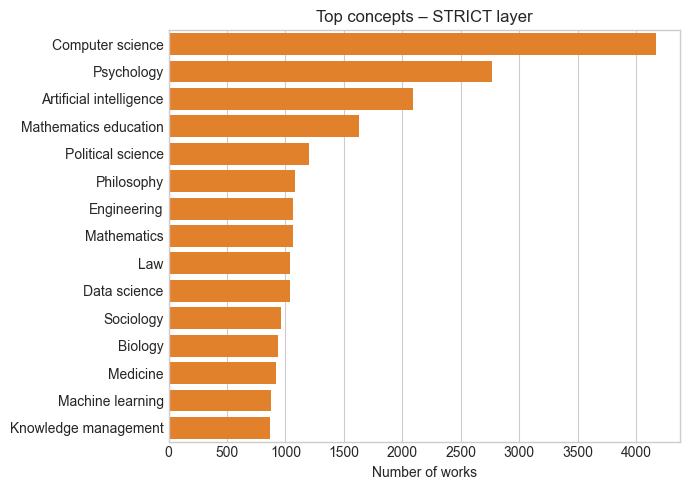

In [65]:
strict_concepts_flat = [
    c
    for lst in df_strict["concepts_list"]
    if lst
    for c in lst
]

concept_counts_strict = Counter(strict_concepts_flat)

top_concepts_strict = (
    pd.Series(concept_counts_strict)
    .sort_values(ascending=False)
    .head(15)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "concept"})
)

display(top_concepts_strict)

plt.figure(figsize=(7,5))
sns.barplot(data=top_concepts_strict, x="count", y="concept", color="tab:orange")
plt.title("Top concepts – STRICT layer")
plt.xlabel("Number of works")
plt.ylabel("")
plt.tight_layout()
plt.show()



### 3.5 Top concepts (STRICT)

,topic,count
0,Online Learning and Analytics,1359
1,Innovative Teaching and Learning Methods,553
2,E-Learning and Knowledge Management,470
3,Online and Blended Learning,388
4,Intelligent Tutoring Systems and Adaptive Lear...,343
5,Educational Games and Gamification,334
6,Artificial Intelligence in Healthcare and Educ...,286
7,Educational Innovations and Technology,222
8,Teaching and Learning Programming,183
9,Topic Modeling,180


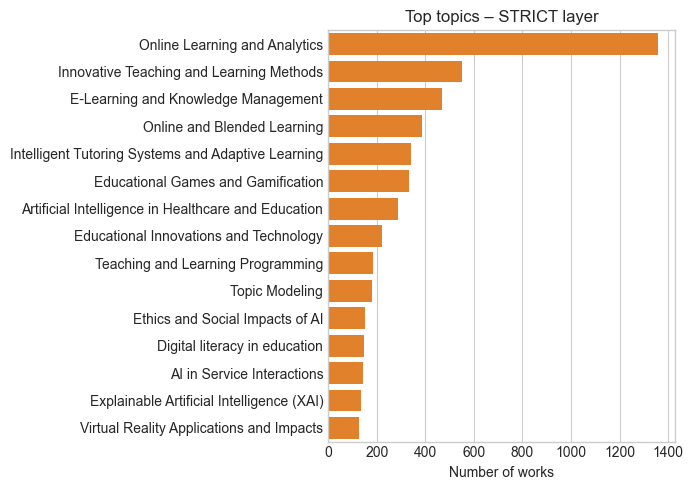

In [67]:
strict_topics_flat = [
    t
    for lst in df_strict["topics_list"]
    if lst
    for t in lst
]

topic_counts_strict = Counter(strict_topics_flat)

top_topics_strict = (
    pd.Series(topic_counts_strict)
    .sort_values(ascending=False)
    .head(15)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "topic"})
)

display(top_topics_strict)

plt.figure(figsize=(7,5))
sns.barplot(data=top_topics_strict, x="count", y="topic", color="tab:orange")
plt.title("Top topics – STRICT layer")
plt.xlabel("Number of works")
plt.ylabel("")
plt.tight_layout()
plt.show()


### 3.5 Institution stats (STRICT) – use aggregated file

In [68]:
inst_strict = pd.read_csv("institutions_STRICT_aggregated.csv")

# top by works_count
top_institutions_strict_works = (
    inst_strict.sort_values("works_count", ascending=False)
    .head(10)
    [["institution_name", "country_code", "works_count", "citations_sum"]]
)

display(top_institutions_strict_works)

# top by citations_sum (if you want a separate table)
top_institutions_strict_cit = (
    inst_strict.sort_values("citations_sum", ascending=False)
    .head(10)
    [["institution_name", "country_code", "citations_sum", "works_count"]]
)

display(top_institutions_strict_cit)


,institution_name,country_code,works_count,citations_sum
993,Utrecht University,NL,96,1603
821,University of Eastern Finland,FI,81,3150
804,Universidad de Granada,ES,72,2200
3230,Technical University of Munich,DE,67,5591
3606,University of Oulu,FI,65,4308
3361,Open University of the Netherlands,NL,58,1865
3447,KTH Royal Institute of Technology,SE,58,1393
202,Universidad Complutense de Madrid,ES,58,730
305,Centre National de la Recherche Scientifique,FR,57,3126
547,Radboud University Nijmegen,NL,57,1980


,institution_name,country_code,citations_sum,works_count
3230,Technical University of Munich,DE,5591,67
3396,Ludwig-Maximilians-Universität München,DE,4946,51
3066,University College London,GB,4544,40
879,Georgia State University,US,4469,4
3606,University of Oulu,FI,4308,65
3605,Delft University of Technology,NL,4252,52
3611,University of Edinburgh,GB,3743,41
3559,University of Bologna,IT,3731,26
875,Friedrich-Alexander-Universität Erlangen-Nürnberg,DE,3572,20
48,University of Central Florida,US,3537,14


### 3.6 Author stats (STRICT) – use author file

In [69]:
authors_strict = pd.read_csv("authors_STRICT_with_key_flag.csv")

top_authors_strict = (
    authors_strict.sort_values("papers_since_2020", ascending=False)
    .head(10)
    [["author_name", "works_count", "papers_since_2020", "citations_sum", "is_key_researcher"]]
)

display(top_authors_strict)


,author_name,works_count,papers_since_2020,citations_sum,is_key_researcher
12901,Christos Troussas,33,33,921,True
10737,Mohammed Saqr,30,30,1144,True
7560,Hendrik Drachsler,29,29,900,True
10516,Cleo Sgouropoulou,26,26,783,True
12775,Ahmed Tlili,24,24,1579,True
7923,Akrivi Krouska,24,24,723,True
8828,Dragan Gašević,22,22,960,True
11966,Dirk Ifenthaler,21,21,1205,True
8761,Olga Viberg,20,20,430,True
8598,Sonsoles López‐Pernas,19,19,452,True


## 4. Visual comparison: ALL vs STRICT

### 4.1 Publications per year – combined plot

<Figure size 700x400 with 0 Axes>

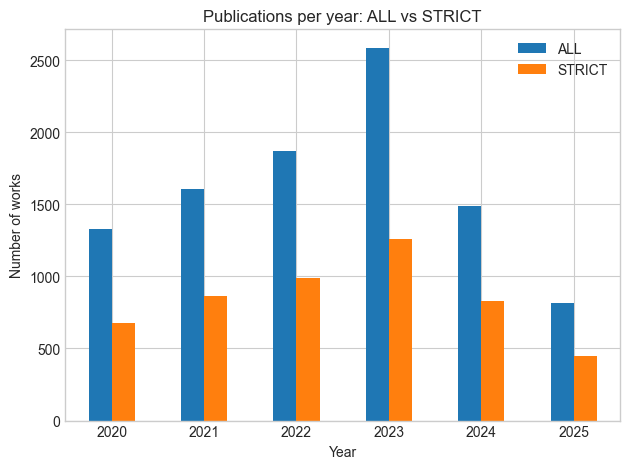

In [70]:
# align years
years = sorted(set(pubs_year_all.index) | set(pubs_year_strict.index))
pubs_compare = pd.DataFrame({
    "ALL": pubs_year_all.reindex(years, fill_value=0),
    "STRICT": pubs_year_strict.reindex(years, fill_value=0),
})

plt.figure(figsize=(7,4))
pubs_compare.plot(kind="bar")
plt.title("Publications per year: ALL vs STRICT")
plt.xlabel("Year")
plt.ylabel("Number of works")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 4.2 OA share – side-by-side bars

C:\Users\hamza\AppData\Local\Temp\ipykernel_13852\3111715821.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=oa_df, x="dataset", y="oa_share", palette=["tab:blue", "tab:orange"])


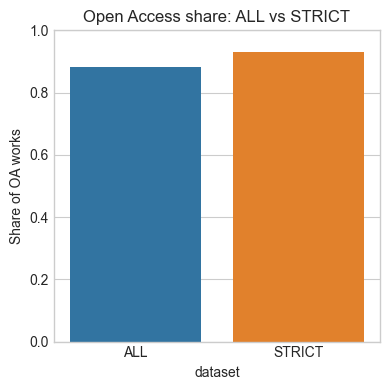

  dataset  oa_share
0     ALL  0.881515
1  STRICT  0.931082


In [71]:
oa_share_all = oa_counts_all.get(True,0) / oa_counts_all.sum()
oa_share_strict = oa_counts_strict.get(True,0) / oa_counts_strict.sum()

oa_df = pd.DataFrame({
    "dataset": ["ALL", "STRICT"],
    "oa_share": [oa_share_all, oa_share_strict],
})

plt.figure(figsize=(4,4))
sns.barplot(data=oa_df, x="dataset", y="oa_share", palette=["tab:blue", "tab:orange"])
plt.title("Open Access share: ALL vs STRICT")
plt.ylabel("Share of OA works")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

print(oa_df)


### 4.3 Compare top venues

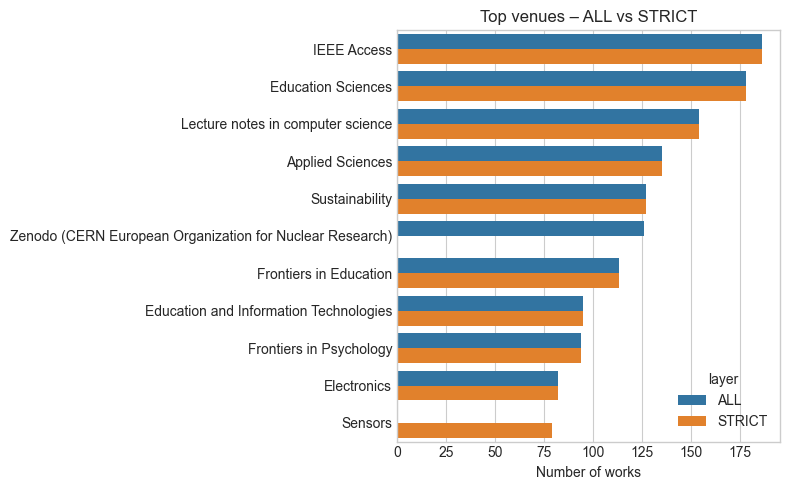

In [72]:
# mark layer and concatenate
ts_all = top_sources_all.copy()
ts_all["layer"] = "ALL"

ts_strict = top_sources_strict[["source_name", "works_count"]].copy()
ts_strict["layer"] = "STRICT"

sources_both = pd.concat([ts_all, ts_strict], ignore_index=True)

plt.figure(figsize=(8,5))
sns.barplot(
    data=sources_both,
    x="works_count", y="source_name", hue="layer"
)
plt.title("Top venues – ALL vs STRICT")
plt.xlabel("Number of works")
plt.ylabel("")
plt.tight_layout()
plt.show()


### 4.4 Compare top concepts

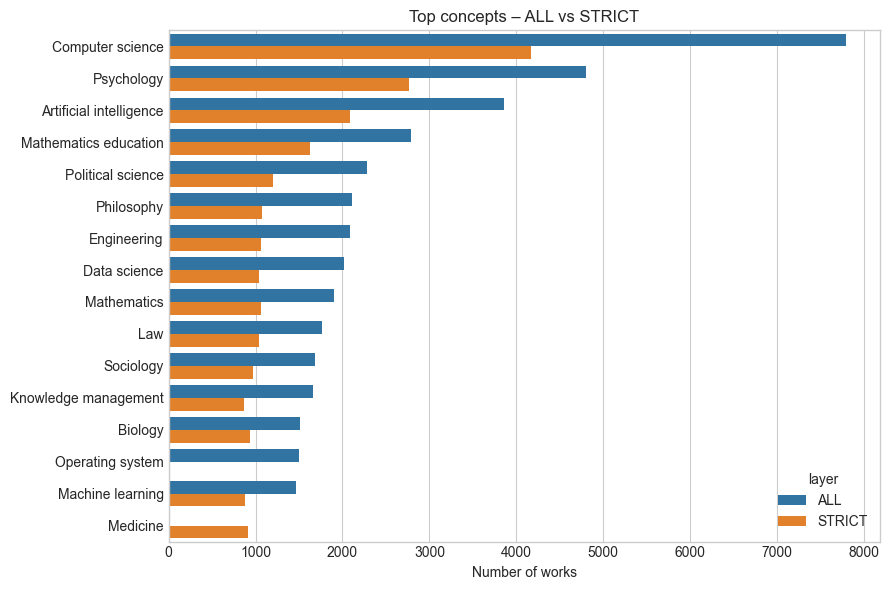

In [73]:
tc_all = top_concepts_all.copy()
tc_all["layer"] = "ALL"

tc_strict = top_concepts_strict.copy()
tc_strict["layer"] = "STRICT"

concepts_both = pd.concat([tc_all, tc_strict], ignore_index=True)

plt.figure(figsize=(9,6))
sns.barplot(
    data=concepts_both,
    x="count", y="concept", hue="layer"
)
plt.title("Top concepts – ALL vs STRICT")
plt.xlabel("Number of works")
plt.ylabel("")
plt.tight_layout()
plt.show()



### 4.5 Compare top topics

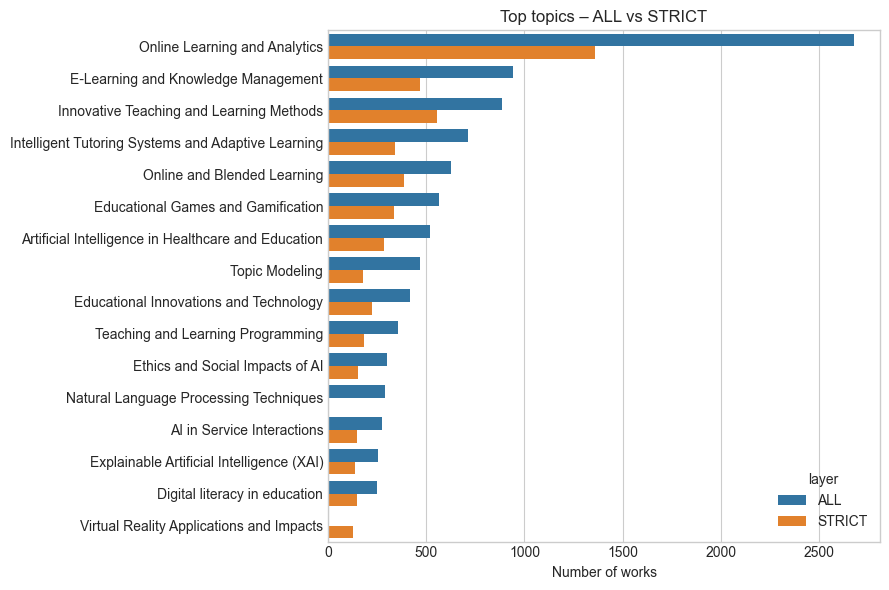

In [ ]:
tt_all = top_topics_all.copy()
tt_all["layer"] = "ALL"

tt_strict = top_topics_strict.copy()
tt_strict["layer"] = "STRICT"

topics_both = pd.concat([tt_all, tt_strict], ignore_index=True)

plt.figure(figsize=(9,6))
sns.barplot(
    data=topics_both,
    x="count", y="topic", hue="layer"
)
plt.title("Top topics – ALL vs STRICT")
plt.xlabel("Number of works")
plt.ylabel("")
plt.tight_layout()
plt.show()
